In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import shutil

# Step 1: Find your dataset root
input_root = "/kaggle/input"

# (Optional) print structure to locate your dataset
for dirname, _, filenames in os.walk(input_root):
    print(dirname)

print("Files Loaded")

#actual dataset path after inspecting above
dataset_path = "/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data"


# Step 2: Create output folders
output_path = "/kaggle/working/dataset_new"

os.makedirs(os.path.join(output_path, "negative"), exist_ok=True)
os.makedirs(os.path.join(output_path, "neutral"), exist_ok=True)
os.makedirs(os.path.join(output_path, "positive"), exist_ok=True)

# Step 3: Define class groups
negative_classes = ["angry", "disgust", "fear", "sad"]
neutral_classes = ["neutral"]
positive_classes = ["happy"]

# Step 4: Copy function
def copy_images(class_list, target_folder):
    for cls in class_list:
        class_path = os.path.join(dataset_path, cls)
        
        if not os.path.exists(class_path):
            print(f"Skipping missing folder: {cls}")
            continue
        
        for file in os.listdir(class_path):
            src = os.path.join(class_path, file)
            dst = os.path.join(output_path, target_folder, f"{cls}_{file}")
            
            shutil.copy(src, dst)

# Step 5: Run it
copy_images(negative_classes, "negative")
copy_images(neutral_classes, "neutral")
copy_images(positive_classes, "positive")

print("Data Relabeled")

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/fahadullaha
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/surprise
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/fear
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/angry
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/neutral
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/sad
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/disgust
/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data/happy
Files Loaded
Data Relabeled


In [3]:
#Check if images were loaded successfully
base = "/kaggle/working/dataset_new"
for cls in os.listdir(base):
    print(cls, len(os.listdir(os.path.join(base, cls))))

positive 11398
neutral 8166
negative 24295


In [4]:
from sklearn.model_selection import train_test_split

base = "/kaggle/working/dataset_new"
train_dir = "/kaggle/working/train"
val_dir = "/kaggle/working/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for cls in os.listdir(base):
    files = os.listdir(os.path.join(base, cls))
    
    train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)
    
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    
    for f in train_files:
        shutil.copy(os.path.join(base, cls, f),
                    os.path.join(train_dir, cls, f))
        
    for f in val_files:
        shutil.copy(os.path.join(base, cls, f),
                    os.path.join(val_dir, cls, f))

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("/kaggle/working/train", transform=transform)
val_data = datasets.ImageFolder("/kaggle/working/val", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers = 2)
val_loader = DataLoader(val_data, batch_size=32, num_workers = 2)

In [6]:
class Net(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.activation = activation

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(self.activation(self.conv1(x)))
        x = self.pool(self.activation(self.conv2(x)))

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = self.activation(self.fc1(x))
        x = self.fc2(x)

        return x

In [7]:
# activation functions to test
activations = {
    "ReLU" : nn.ReLU(),
    "LeakyReLU":  nn.LeakyReLU(0.1),
    "SiLU" : nn.SiLU(),
    "Sigmoid" : nn.Sigmoid()
}

In [8]:
epochs = 5
results = {}

for func_name, activation in activations.items():
    print(f"===Training with {func_name}===")

    net = Net(activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        # Train
        net.train()
        running_loss, num_batches = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        train_losses.append(avg_loss)

        # Validate
        net.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = net(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        test_accuracies.append(test_acc)
        print(f"Epoch {epoch + 1:02d}/{epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

    results[func_name] = {"train_losses": train_losses, "test_accuracies": test_accuracies}

===Training with ReLU===
Epoch 01/5, Loss: 0.8583, Test Accuracy: 64.33%
Epoch 02/5, Loss: 0.7402, Test Accuracy: 65.21%
Epoch 03/5, Loss: 0.6838, Test Accuracy: 69.87%
Epoch 04/5, Loss: 0.6419, Test Accuracy: 71.75%
Epoch 05/5, Loss: 0.6082, Test Accuracy: 72.88%
===Training with LeakyReLU===
Epoch 01/5, Loss: 0.8470, Test Accuracy: 66.18%
Epoch 02/5, Loss: 0.7058, Test Accuracy: 69.67%
Epoch 03/5, Loss: 0.6438, Test Accuracy: 71.73%
Epoch 04/5, Loss: 0.6047, Test Accuracy: 72.78%
Epoch 05/5, Loss: 0.5797, Test Accuracy: 72.34%
===Training with SiLU===
Epoch 01/5, Loss: 0.8714, Test Accuracy: 63.98%
Epoch 02/5, Loss: 0.7371, Test Accuracy: 68.62%
Epoch 03/5, Loss: 0.6753, Test Accuracy: 70.44%
Epoch 04/5, Loss: 0.6385, Test Accuracy: 71.30%
Epoch 05/5, Loss: 0.6094, Test Accuracy: 72.96%
===Training with Sigmoid===
Epoch 01/5, Loss: 0.9804, Test Accuracy: 58.06%
Epoch 02/5, Loss: 0.9021, Test Accuracy: 58.06%
Epoch 03/5, Loss: 0.8650, Test Accuracy: 62.05%
Epoch 04/5, Loss: 0.8409, Te

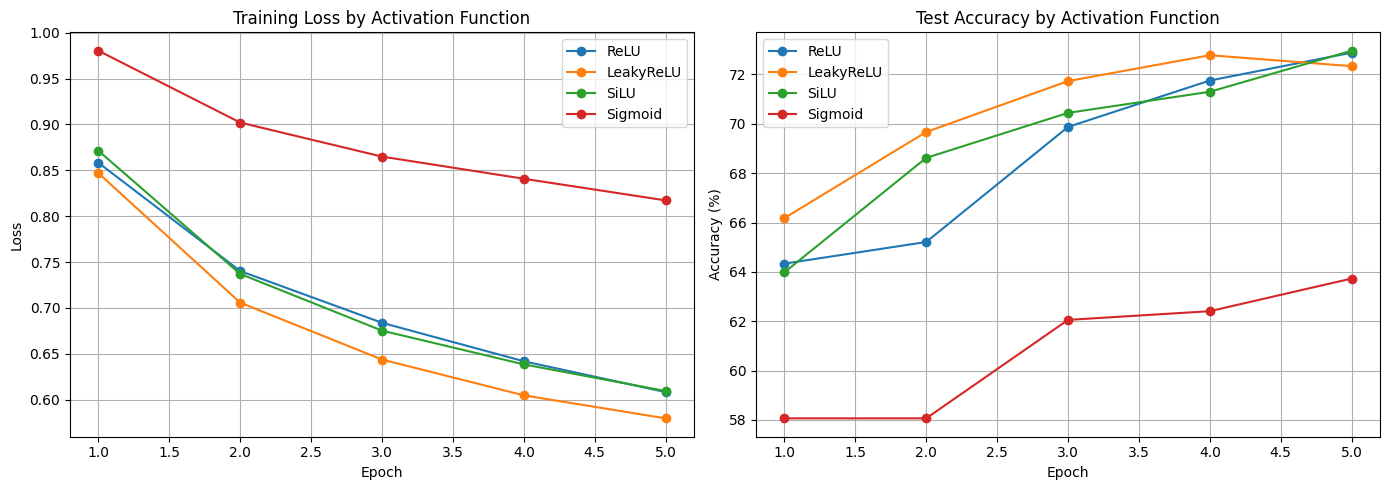

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epoch_range = range(1, epochs + 1)

for name, data in results.items():
    ax1.plot(epoch_range, data["train_losses"], marker='o', label=name)
    ax2.plot(epoch_range, data["test_accuracies"], marker='o', label=name)

ax1.set_title("Training Loss by Activation Function")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.set_title("Test Accuracy by Activation Function")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# select the model with the best activation function
best_activation_name = max(results, key=lambda k: max(results[k]["test_accuracies"]))
best_acc = max(results[best_activation_name]["test_accuracies"])

print(f"Best activation chosen: {best_activation_name} with an accuracy of {best_acc:.2f}%")

Best activation chosen: SiLU with an accuracy of 72.96%


In [16]:
# retrain the chosen model to yield the final best weights
best_net = Net(activations[best_activation_name]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_net.parameters(), lr=0.001)

for epoch in range(epochs):
    # Train
    best_net.train()
    running_loss, num_batches = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(best_net(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1
    avg_loss = running_loss / num_batches

    # Validate
    best_net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(best_net(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch + 1:02d}/{epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {acc:.2f}%")

Epoch 01/5, Loss: 0.8659, Test Accuracy: 64.94%
Epoch 02/5, Loss: 0.7243, Test Accuracy: 68.85%
Epoch 03/5, Loss: 0.6812, Test Accuracy: 67.92%
Epoch 04/5, Loss: 0.6483, Test Accuracy: 71.97%
Epoch 05/5, Loss: 0.6205, Test Accuracy: 72.36%


In [31]:
import copy

# saves the best model that way we don't have to waste time running all the code
# above this block.
torch.save({
    "model_state_dict": best_net.state_dict(),
    "activation_name": best_activation_name,
    "classes": train_data.classes,
}, "/kaggle/working/best_model.pth")

print("Success! Model saved.")

Success! Model saved.


In [32]:
# Load saved model
load_model = torch.load("/kaggle/working/best_model.pth", map_location=device)
classes = model["classes"]  # ['negative', 'neutral', 'positive']

best_model = Net(activations[load_model["activation_name"]]).to(device)
best_model.load_state_dict(load_model["model_state_dict"])
best_model.eval()

print("Successfully loaded model!")

Successfully loaded model!


In [37]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import io

transform_infer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def predict_image(img: Image.Image):
    tensor = transform_infer(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(inference_net(tensor), dim=1)[0]
        pred = torch.argmax(probs).item()
    label = classes[pred]
    confidence = probs[pred].item() * 100

    print(f"\nPrediction: {label.upper()}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nAll scores:\t")
    for i, cls in enumerate(classes):
        print(f"{cls:<10} {probs[i].item()*100:.2f}%")

# creates an upload button to test images
upload_btn = widgets.FileUpload(accept="image/*", multiple=False)
output = widgets.Output()

# triggers when image is uploaded
def on_upload(change):
    output.clear_output()
    with output:
        uploaded_file = upload_btn.value[0]
        img = Image.open(io.BytesIO(uploaded_file["content"])).convert("RGB")
        display(img.resize((200, 200)))
        predict_image(img)

# links upload button to on_upload trigger
upload_btn.observe(on_upload, names="value")
display(upload_btn, output)

FileUpload(value=(), accept='image/*', description='Upload')

Output()